In [10]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')

In [11]:
sun_radius = 0.00465047 #AU
sun_mu = 0.01720209895**2 #AU^3/day^2

Video 1 (Click to open)

[![Video](https://img.youtube.com/vi/nJ_f1h49jfM/0.jpg)](https://www.youtube.com/watch?v=nJ_f1h49jfM&list=PLOIRBaljOV8hBJS4m6brpmUrncqkyXBjB&index=1)

Notes for Video 1

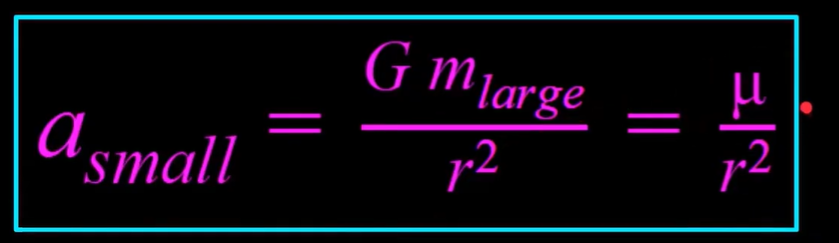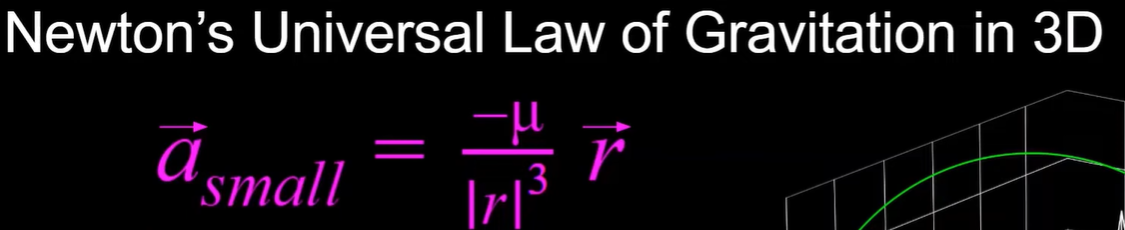

In [12]:
def two_body_ode(t, state):
    
    r = state[:3]
    a = -sun_mu * r / np.linalg.norm(r)**3
    
    return np.array([
        state[3], # x
        state[4], # y
        state[5], # z
        a[0], # vx
        a[1], # vy 
        a[2]  # vz
        ])

Video 2 (Click to open)

[![Video](https://img.youtube.com/vi/8-SyHZb7w40/0.jpg)](https://www.youtube.com/watch?v=8-SyHZb7w40&list=PLOIRBaljOV8hBJS4m6brpmUrncqkyXBjB&index=2)

Notes for Video 2

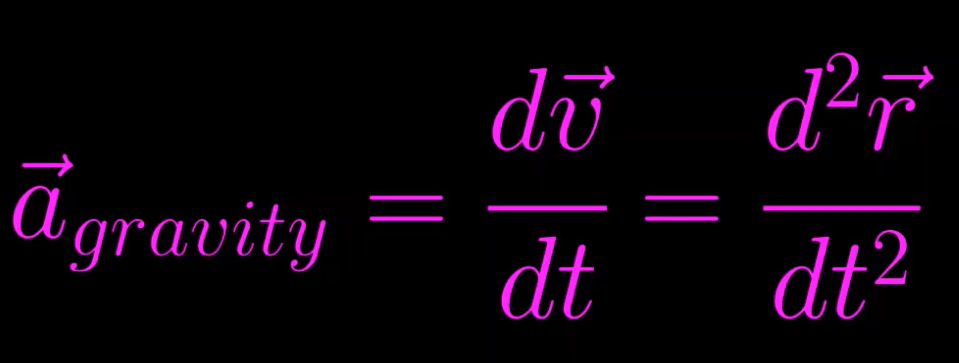

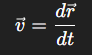

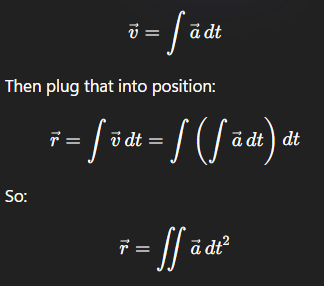

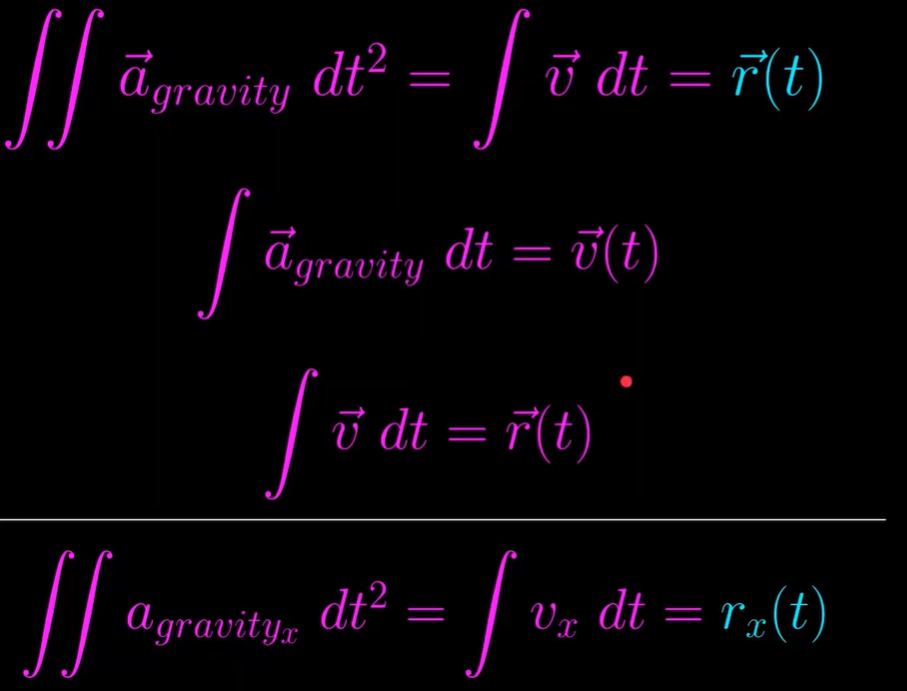

Video 3 (Click to open)

[![Video](https://img.youtube.com/vi/VrH6JhIFmcA/0.jpg)](https://www.youtube.com/watch?v=VrH6JhIFmcA&list=PLOIRBaljOV8hBJS4m6brpmUrncqkyXBjB&index=3)

Notes for Video 3

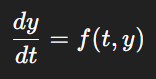

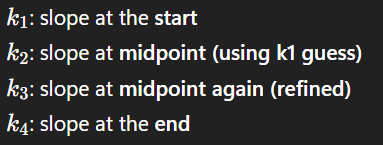

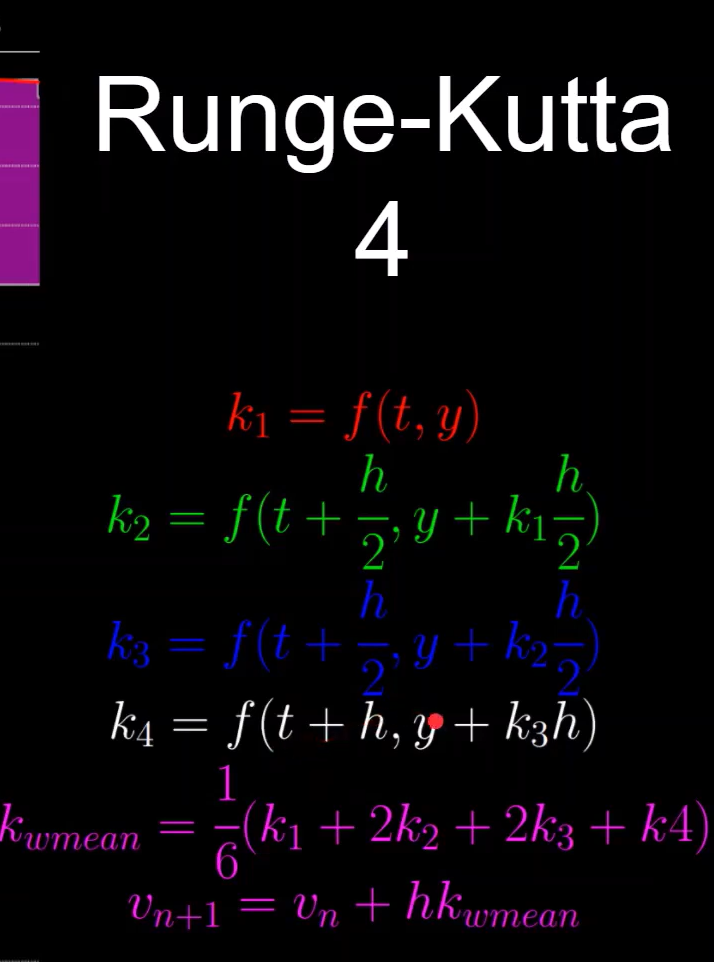

In [13]:
def rk4_step(f, t, y, h):
    
    k1 = f(t, y)
    k2 = f(t+h/2, y + k1*(h/2))
    k3 = f(t+h/2, y + k2*(h/2))
    k4 = f(t+h, y + k3*h)
    
    return y+h / 6 * (k1 + 2*k2 + 2*k3 + k4)

Video 4 (Click to Open)

[![Video](https://img.youtube.com/vi/TzX6bg3Kc0E/0.jpg)](https://www.youtube.com/watch?v=TzX6bg3Kc0E&list=PLOIRBaljOV8hBJS4m6brpmUrncqkyXBjB&index=4)

Notes for Video 4

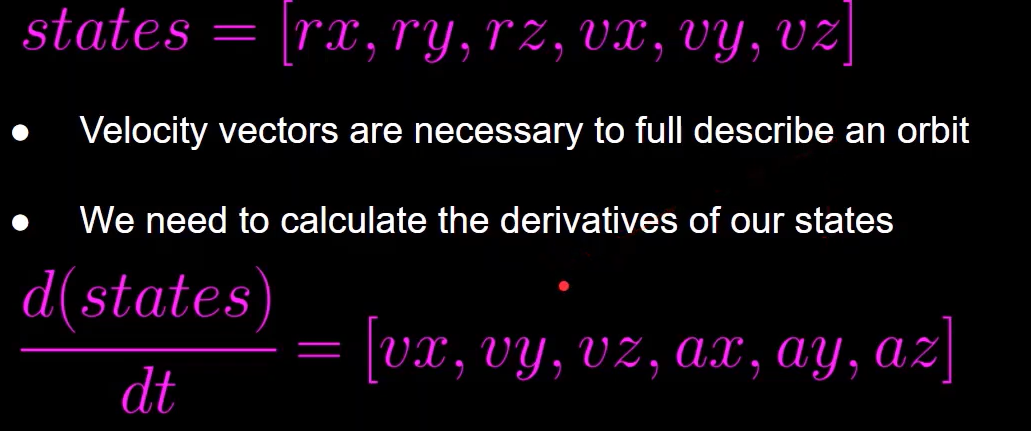

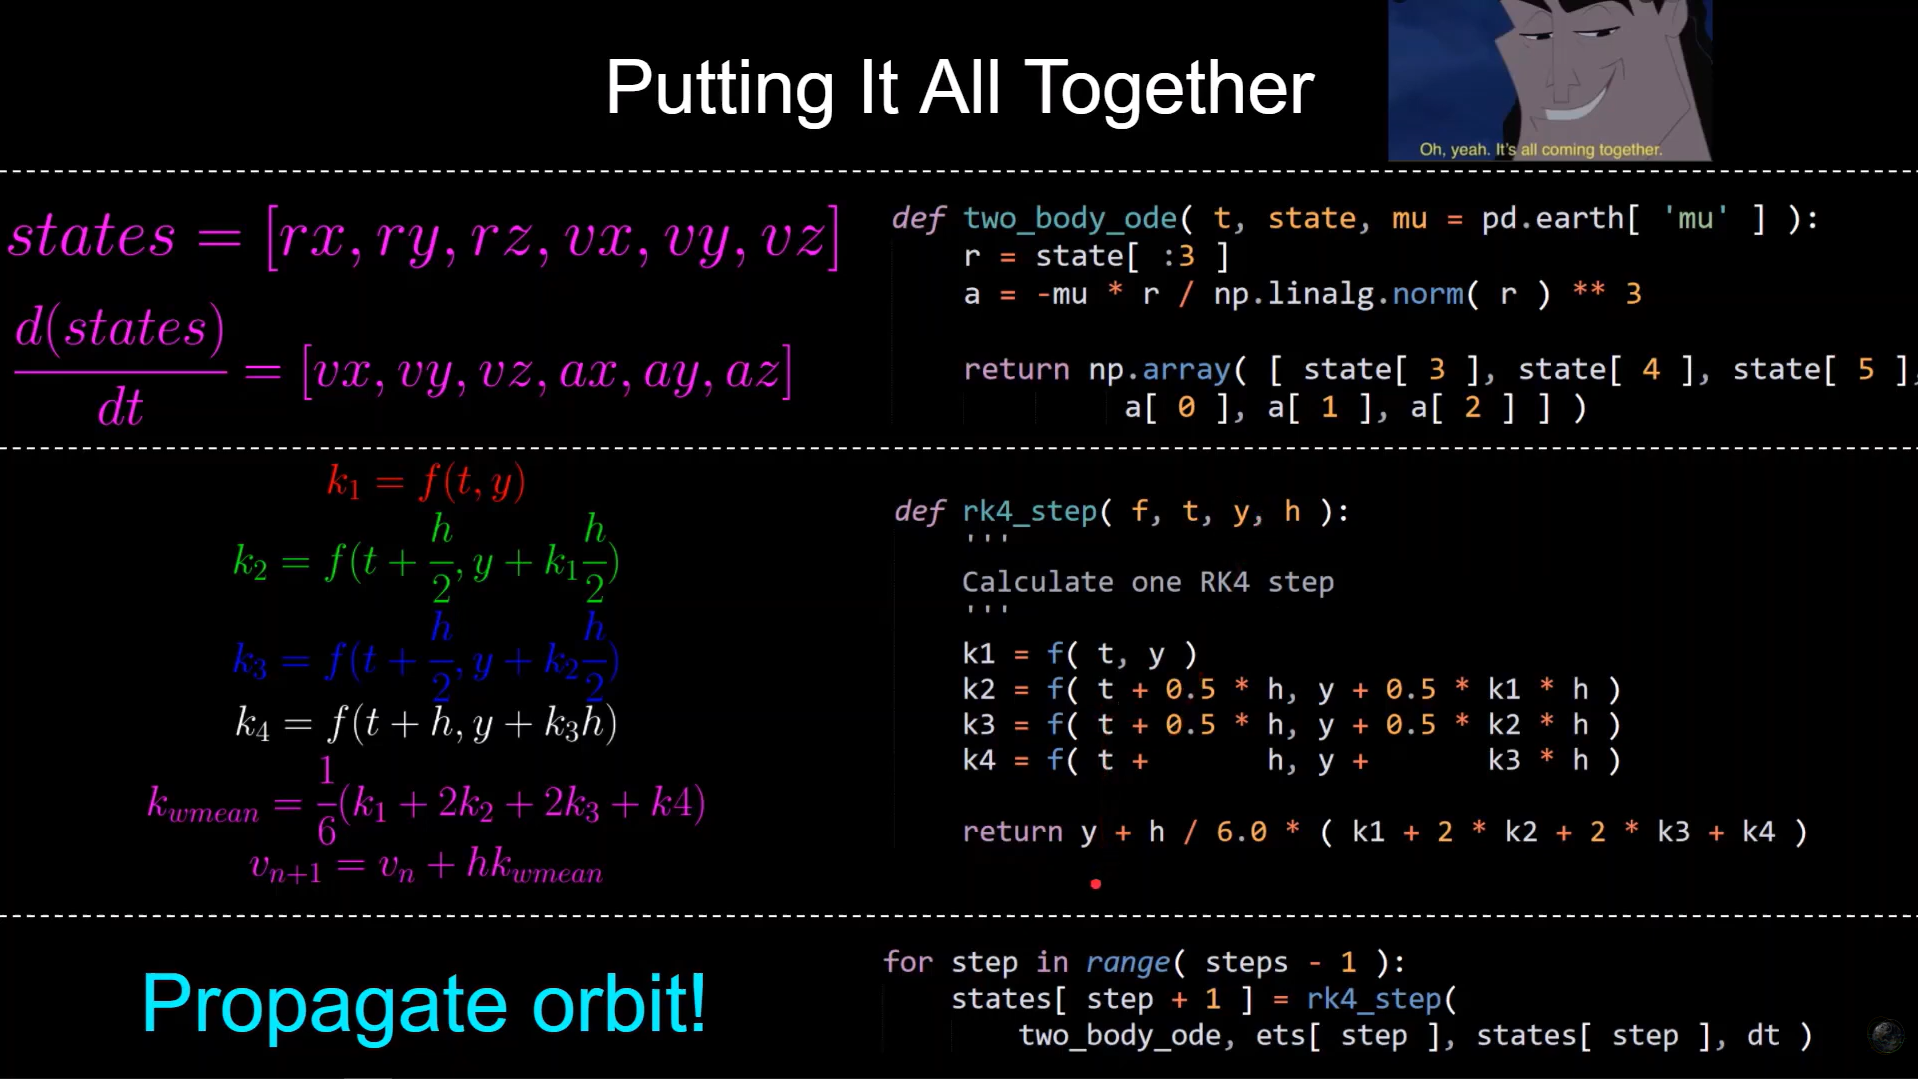

In [22]:
def plot_orbits(rs, args):
    _args = {
        'figsize'      : ( 10, 8 ),
		'labels'       : [ '' ] * len( rs ),
		'colors'       : [ 'm', 'c', 'r', 'C3' ],
		'traj_lws'     : 3,
		'dist_unit'    : 'AU',
		'groundtracks' : False,
		'cb_radius'    : 6378.0,
		'cb_SOI'       : None,
		'cb_SOI_color' : 'c',
		'cb_SOI_alpha' : 0.7,
		'cb_axes'      : True,
		'cb_axes_mag'  : 2,
		'cb_cmap'      : 'Blues',
		'cb_axes_color': 'w',
		'axes_mag'     : 0.8,
		'axes_custom'  : None,
		'title'        : 'Trajectories',
		'legend'       : True,
		'axes_no_fill' : True,
		'hide_axes'    : False,
		'azimuth'      : False,
		'elevation'    : False,
		'show'         : False,
		'filename'     : False,
		'dpi'          : 300
    }
    
    for key in args.keys():
        _args[key] = args[key]
        
    fig = plt.figure(figsize = _args['figsize'])
    ax  = fig.add_subplot(111, projection = '3d')
    
    max_val = 0
    n       = 0
    
    for r in rs:
        ax.plot( r[ :, 0 ], r[ :, 1 ], r[ : , 2 ],
            color = _args[ 'colors' ][ n ], label = _args[ 'labels' ][ n ],
            zorder = 10, linewidth = _args[ 'traj_lws' ] )
        ax.plot( [ r[ 0, 0 ] ], [ r[ 0 , 1 ] ], [ r[ 0, 2 ] ], 'o',
            color = _args[ 'colors' ][ n ] )

        if _args[ 'groundtracks' ]:
            rg  = r[ : ] / np.linalg.norm( r, axis = 1 ).reshape( ( r.shape[ 0 ], 1 ) )
            rg *= _args[ 'cb_radius' ]

            ax.plot( rg[ :, 0 ], rg[ :, 1 ], rg[ :, 2 ], cs[ n ], zorder = 10 )
            ax.plot( [ rg[ 0, 0 ] ], [ rg[ 0, 1 ] ], [ rg[ 0, 2 ] ], cs[ n ] + 'o', zorder = 10 )			

        max_val = max( [ r.max(), max_val ] )
        n += 1
        
    _u, _v = np.mgrid[ 0:2*np.pi:20j, 0:np.pi:20j ]
    _x     = _args[ 'cb_radius' ] * np.cos( _u ) * np.sin( _v )
    _y     = _args[ 'cb_radius' ] * np.sin( _u ) * np.sin( _v )
    _z     = _args[ 'cb_radius' ] * np.cos( _v )
    ax.plot_surface( _x, _y, _z, cmap = _args[ 'cb_cmap' ], zorder = 1 )

    if _args[ 'cb_axes' ]:
        l       = _args[ 'cb_radius' ] * _args[ 'cb_axes_mag' ]
        x, y, z = [ [ 0, 0, 0 ], [ 0, 0, 0  ], [ 0, 0, 0 ] ]
        u, v, w = [ [ l, 0, 0 ], [ 0, l, 0 ], [ 0, 0, l ] ]
        ax.quiver( x, y, z, u, v, w, color = _args[ 'cb_axes_color' ] )
  
    xlabel = 'X (%s)' % _args[ 'dist_unit' ]
    ylabel = 'Y (%s)' % _args[ 'dist_unit' ]
    zlabel = 'Z (%s)' % _args[ 'dist_unit' ]
 
    if _args[ 'axes_custom' ] is not None:
        max_val = _args[ 'axes_custom' ]
    else:
        max_val *= _args[ 'axes_mag' ]
  
    ax.set_xlim( [ -max_val, max_val ] )
    ax.set_ylim( [ -max_val, max_val ] )
    ax.set_zlim( [ -max_val, max_val ] )
    ax.set_xlabel( xlabel )
    ax.set_ylabel( ylabel )
    ax.set_zlabel( zlabel )
    ax.set_box_aspect( [ 1, 1, 1 ] )
    ax.set_aspect( 'auto' )

    if _args[ 'azimuth' ] is not False:
	    ax.view_init( elev = _args[ 'elevation' ],
					  azim = _args[ 'azimuth'   ] )
	
    if _args[ 'axes_no_fill' ]:
	    ax.xaxis.pane.fill = False
	    ax.yaxis.pane.fill = False
	    ax.zaxis.pane.fill = False		

    if _args[ 'hide_axes' ]:
	    ax.set_axis_off()

    if _args[ 'legend' ]:
	    plt.legend()

    if _args[ 'filename' ]:
	    plt.savefig( _args[ 'filename' ], dpi = _args[ 'dpi' ] )
	    print( 'Saved', _args[ 'filename' ] )

    if _args[ 'show' ]:
	    plt.show()

    plt.close()


In [18]:
r0_norm = sun_radius + 450.0
v0_norm = (sun_mu / r0_norm) ** 5
statei = [r0_norm, 0, 0, 0, v0_norm, 0]
tspan = 100.0 * 60.0
dt = 100.0
steps = int(tspan/dt)
ets = np.zeros((steps, 1))
states = np.zeros((steps, 6))
states[0] = statei

[[ 4.50004650e+02  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.22950247e-31  0.00000000e+00]
 [ 4.50004643e+02  1.22950246e-29  0.00000000e+00 -1.46126467e-07
   1.22950245e-31  0.00000000e+00]
 [ 4.50004621e+02  2.45900489e-29  0.00000000e+00 -2.92252943e-07
   1.22950239e-31  0.00000000e+00]
 [ 4.50004585e+02  3.68850723e-29  0.00000000e+00 -4.38379439e-07
   1.22950229e-31  0.00000000e+00]
 [ 4.50004534e+02  4.91800945e-29  0.00000000e+00 -5.84505962e-07
   1.22950215e-31  0.00000000e+00]
 [ 4.50004468e+02  6.14751151e-29  0.00000000e+00 -7.30632524e-07
   1.22950197e-31  0.00000000e+00]
 [ 4.50004387e+02  7.37701338e-29  0.00000000e+00 -8.76759133e-07
   1.22950175e-31  0.00000000e+00]
 [ 4.50004292e+02  8.60651500e-29  0.00000000e+00 -1.02288580e-06
   1.22950149e-31  0.00000000e+00]
 [ 4.50004183e+02  9.83601635e-29  0.00000000e+00 -1.16901253e-06
   1.22950119e-31  0.00000000e+00]
 [ 4.50004059e+02  1.10655174e-28  0.00000000e+00 -1.31513934e-06
   1.22950085e-31  0.0000

C:\Users\hridd\AppData\Local\Temp\ipykernel_3248\2737108139.py:99: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


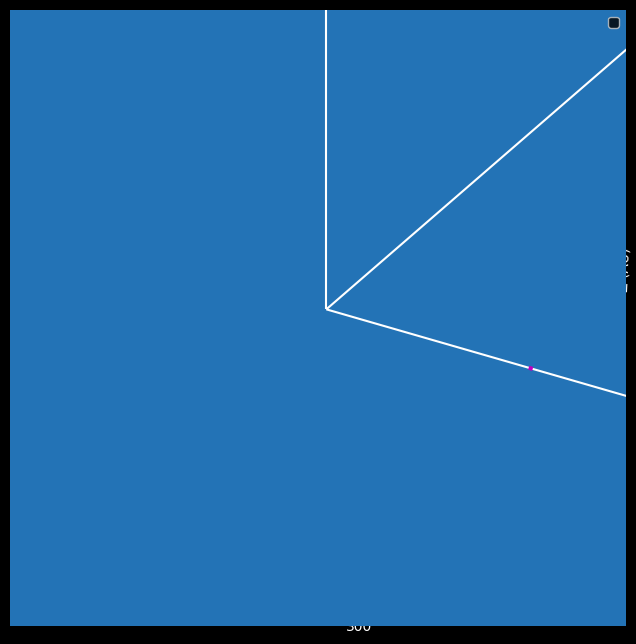

In [23]:
for step in range(steps - 1):
    states[step+1] = rk4_step(
        two_body_ode, ets[step], states[step], dt)
    
print(states)
plot_orbits([states], {'show': True})